Dataset Shape: (7043, 21)
Dataset Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Chu

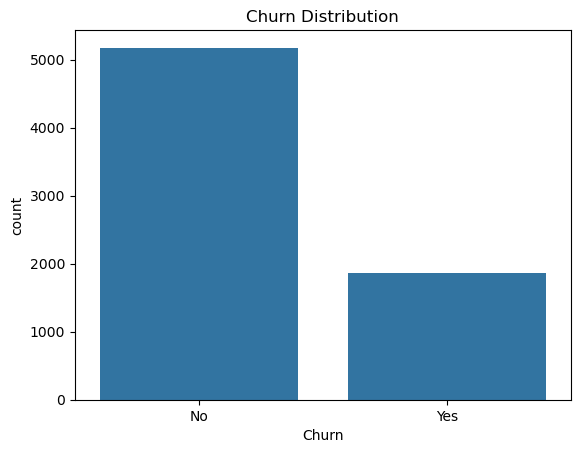

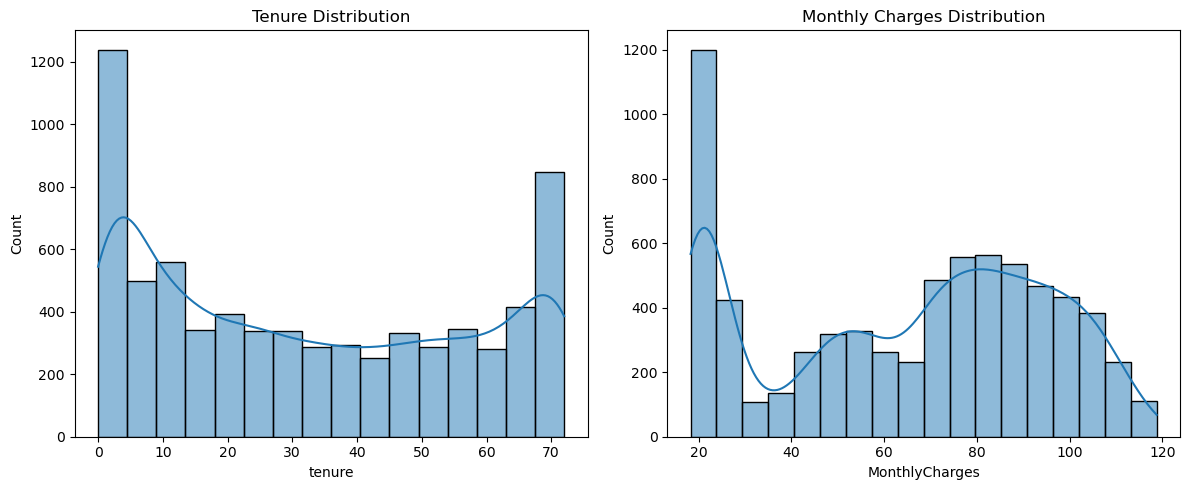

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the Data
# Typically, the dataset would be directly available via a URL or a CSV file in the local directory.
# For this example, assume it is stored in 'telco_customer_churn.csv'.

# Load data into a pandas DataFrame
df = pd.read_csv('/Users/sanjeevsubramanya/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Explore the dataset
print("Dataset Shape:", df.shape)
print("Dataset Columns:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

# Step 2: Check target distribution
# Assuming 'Churn' is the target column indicating customer churn
churn_distribution = df['Churn'].value_counts(normalize=True)

print("\nTarget Distribution (Churn):")
print(churn_distribution)

# Step 3: Visualize the target distribution
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

# Visualize some key features
# For example, let's visualize distribution of tenure and monthly charges
plt.figure(figsize=(12, 5))

# Tenure distribution
plt.subplot(1, 2, 1)
sns.histplot(df['tenure'], kde=True)
plt.title('Tenure Distribution')

# Monthly Charges Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title('Monthly Charges Distribution')

plt.tight_layout()
plt.show()

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Assume 'df' is your DataFrame
# Let's assume you have already loaded 'df' as shown in Step 1

# Step 1: Handle Missing Values
# For simplicity, let's fill missing values with the median for numeric columns
# and with the mode for categorical columns.
for column in df.columns:
    if df[column].dtype == 'object':  # Categorical Columns
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:  # Numeric Columns
        df[column].fillna(df[column].median(), inplace=True)

# Step 2: Convert Categorical Variables to Numeric
# Use Label Encoding for simplicity, though One-Hot Encoding could also be applied
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

# Step 3: Select Relevant Features for Modeling
# Assume we decide to keep all features available for simplicity's sake
# Note: Feature selection should ideally be informed by domain knowledge or statistical methods

# Step 4: Separate Features (X) from Target (y)
# Assume 'Churn' is the target variable
X = df.drop('Churn', axis=1)
y = df['Churn']

# Step 5: Convert Target to Binary (0/1) if Needed
# Assuming 'Churn' is already binary (elaborate this step if more conversion needed)
# Example of explicit conversion if you need it
y = LabelEncoder().fit_transform(y)

# Now you can proceed with a train-test split prior to modeling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Preprocessing Complete")

Data Preprocessing Complete


/var/folders/n8/8n9cd5q52sq9bmhd66xjc_vh0000gn/T/ipykernel_71270/3735697392.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)
/var/folders/n8/8n9cd5q52sq9bmhd66xjc_vh0000gn/T/ipykernel_71270/3735697392.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Assuming 'df' is your preprocessed DataFrame and 'Churn' is the target variable

# Step 1: Prepare Data
# Convert the 'Churn' column to binary if it's not already handled (already done in Step 2)
y = df['Churn']
X = df.drop('Churn', axis=1)

# Step 2: Split the Data
# Use stratify to maintain the class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% test size
    stratify=y,     # Ensure class distribution is maintained
    random_state=42 # For reproducibility
)

# Output some basic info about the split
print(f"Training Set Size: {X_train.shape[0]} rows")
print(f"Testing Set Size: {X_test.shape[0]} rows")
print(f"Class Distribution in Training Set:\n{y_train.value_counts(normalize=True)}")
print(f"Class Distribution in Testing Set:\n{y_test.value_counts(normalize=True)}")

Training Set Size: 5634 rows
Testing Set Size: 1409 rows
Class Distribution in Training Set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Class Distribution in Testing Set:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Assume X_train, X_test, y_train, y_test have already been created from the previous steps

# Step 1: Create a KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)

# Step 2: Train the KNN Model
knn.fit(X_train, y_train)

# Step 3: Make Predictions
y_pred = knn.predict(X_test)

# Step 4: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Optional: Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.70

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81      1035
           1       0.36      0.19      0.25       374

    accuracy                           0.70      1409
   macro avg       0.55      0.53      0.53      1409
weighted avg       0.65      0.70      0.66      1409



Accuracy: 0.70
Precision: 0.36
Recall: 0.19


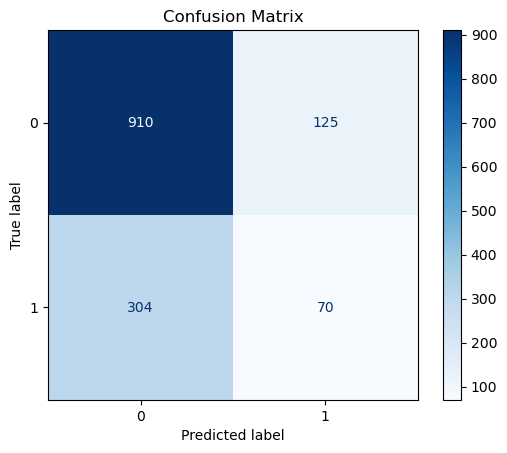


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81      1035
           1       0.36      0.19      0.25       374

    accuracy                           0.70      1409
   macro avg       0.55      0.53      0.53      1409
weighted avg       0.65      0.70      0.66      1409



In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assume X_train, X_test, y_train, y_test have already been created from the previous steps

# Create and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

# Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=knn.classes_).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Generate and print a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

K=1: Accuracy=0.64
K=3: Accuracy=0.68
K=5: Accuracy=0.70
K=7: Accuracy=0.70
K=9: Accuracy=0.71
K=11: Accuracy=0.72
K=15: Accuracy=0.72


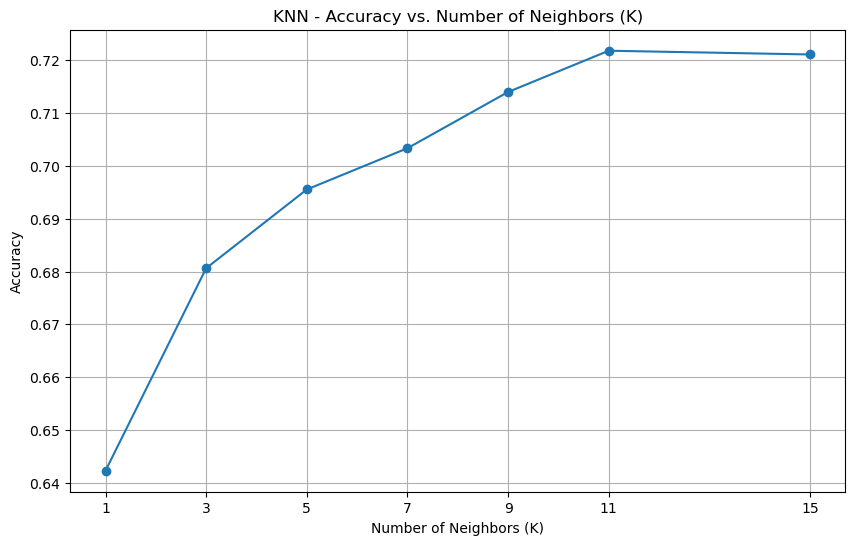

The best K value is 11 with an accuracy of 0.72


In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# List of different K values to try
k_values = [1, 3, 5, 7, 9, 11, 15]

# Dictionary to store accuracy for each k
performance = {}

# Loop over different k values to train and evaluate the model
for k in k_values:
    # Create a KNN classifier with the current k
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Train the model
    knn.fit(X_train, y_train)
    
    # Make predictions
    y_pred = knn.predict(X_test)
    
    # Calculate and store accuracy
    accuracy = accuracy_score(y_test, y_pred)
    performance[k] = accuracy

    # Document the accuracy
    print(f"K={k}: Accuracy={accuracy:.2f}")

# Plotting the accuracies for different K values
plt.figure(figsize=(10, 6))
plt.plot(list(performance.keys()), list(performance.values()), marker='o')
plt.title('KNN - Accuracy vs. Number of Neighbors (K)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Choose the best K value based on accuracy
best_k = max(performance, key=performance.get)
print(f"The best K value is {best_k} with an accuracy of {performance[best_k]:.2f}")


In [9]:
# Assuming you have already calculated accuracy using your best K value
print(f"The model's accuracy with the best K value ({best_k}) is: {performance[best_k]:.2f}")

The model's accuracy with the best K value (11) is: 0.72


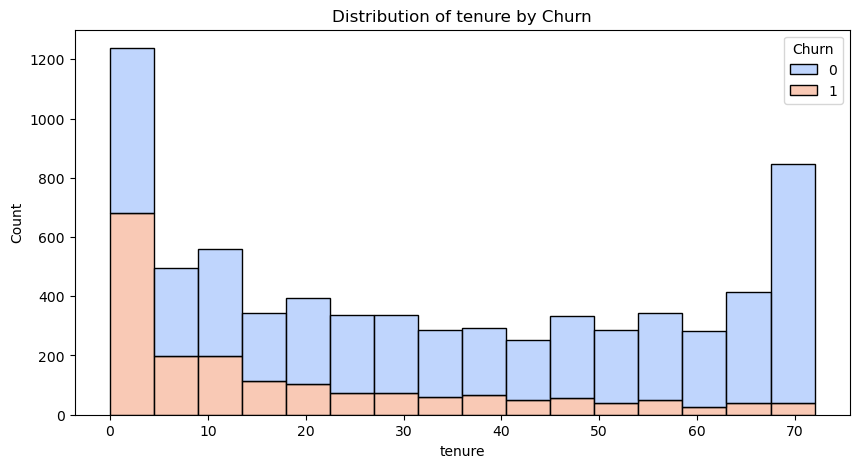

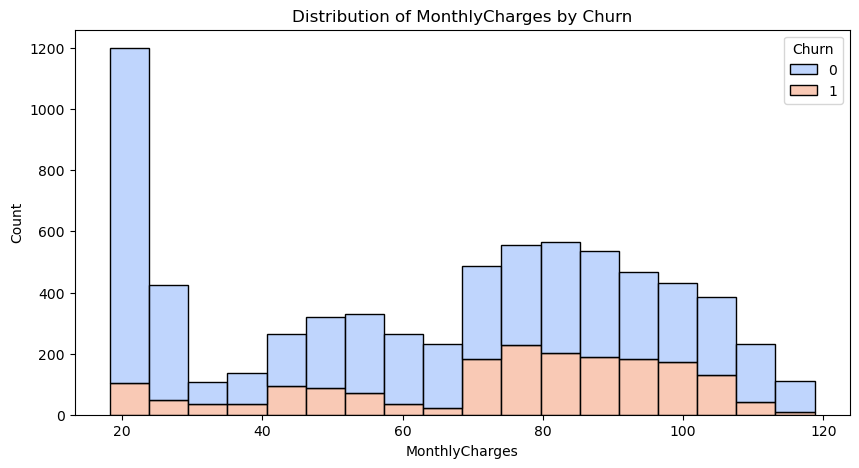

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Exploring feature distributions for a few features
features_to_explore = ['tenure', 'MonthlyCharges']
for feature in features_to_explore:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x=feature, hue='Churn', multiple='stack', palette='coolwarm')
    plt.title(f'Distribution of {feature} by Churn')
    plt.show()